testing ray tracer without paraxial rays

In [151]:
import numpy as np 
import matplotlib.pyplot as plt
import math

In [152]:
#the boundary itself does not count as surface
def pointInPolygon(xp,yp,polygonX,polygonY):
    inside=False
    
    for i in range(len(polygonX)):
        x1=polygonX[i]
        y1=polygonY[i]
        #so the last point loops back to the first
        x2=polygonX[(i+1)%len(polygonX)]
        y2=polygonY[(i+1)%len(polygonX)]

        if (x1==x2) and (y1==y2):
            continue

        # does yp lie between y1 and y2, indepedent of which is greater
        if (y1 > yp) != (y2 > yp):

            xi = x1 + (yp - y1) * (x2 - x1) / (y2 - y1)
            # x-coordinate of the intersection with horizontal ray travelling in positive x

            # if the intersection is to the right of the point, this means that the ray will cross
            if xi > xp:
                inside = not inside

    return inside

#does not deal with vertical rays, will add later, find the tangent angle of the nearest boundary
def closestBoundaryCrossed_TangentAngle(xp,yp,angle,polygonX,polygonY):
    #slope of the line, doesnt work for vertical slope
    mp = math.tan(angle)
    min_distance_squared = float('inf')
    min_Index = None
    
    for i in range(len(polygonX)):
        x1=polygonX[i]
        y1=polygonY[i]
        #so the last point loops back to the first
        x2=polygonX[(i+1)%len(polygonX)]
        y2=polygonY[(i+1)%len(polygonX)]

        #if points repeated
        if (x1==x2) and (y1==y2):
            continue
        #vertical 
        if x2==x1: 
            xi=x1
            yi=mp*(xi-xp)+yp
        else: 
            m1 = (y2-y1)/(x2-x1)
            if m1==mp:
                continue
            xi = (m1*x1-mp*xp-y1+yp)/(m1-mp)
            yi = mp*(xi-xp)+yp

        #if intersection is within line segment 
        if min(x1,x2) <= xi <= max(x1,x2) and min(y1,y2) <= yi <= max(y1,y2):
            #taking dot product to see if vector xp -> xi is in the same direction as angle vector
            dx = math.cos(angle)
            dy = math.sin(angle)
            
            vx = xi-xp
            vy = yi-yp
            #if travelling in the same direction, then the intersection is in the path
            if dx*vx + dy*vy > 0:
                d_squared = (xi-xp)**2 + (yi-yp)**2 
                if d_squared<min_distance_squared:
                    min_distance_squared=d_squared
                    min_Index=i
    if min_Index is None: 
        return None
    else: 
        dx = (polygonX[min_Index]-polygonX[(min_Index+1)%len(polygonX)])
        dy = (polygonY[min_Index]-polygonY[(min_Index+1)%len(polygonY)])
        return math.atan(-dx/dy)
        
def refracted_angle(theta_1,theta_t,n1,n2):
    return math.arcsin((n1/n2)*math.sin(theta_1-theta_t))+theta_t
        

In [153]:
#global variable
objects = []   # stores all objects    

class backgroundMedium:
    def __init__(self, n):
        self.refractiveIndex=n
        #make sure that background Medium is first object
        objects.insert(0,self)


#ray class
class Ray:
    step=0.1
    rays = []
    
    def __init__(self, y_pos, theta, x_pos=0):
        self.ypos = y_pos
        self.xpos = x_pos
        #why must math module do everything in radians????
        self.angle= math.radians(theta)
        self.x_history = [x_pos]
        self.y_history = [y_pos]

        #starts in air
        self.currentObjectIndex=0        
                
        Ray.rays.append(self)
        objects.append(self)
        
    #move small amount in direction theta
    def move_step(self):
        self.ypos=self.ypos+Ray.step*math.sin(self.angle)
        self.xpos=self.xpos+Ray.step*math.cos(self.angle)
        
        self.x_history.append(self.xpos)
        self.y_history.append(self.ypos) 

        #default is background medium
        objectIndex=0
        
        for i in range(len(objects)):
            obj = objects[i]
            if isinstance(obj, Circle): 
                isCurrentPointInCircle = pointInPolygon(xp=self.xpos,yp=self.ypos,polygonX=obj.allX,polygonY=obj.allY)
                if isCurrentPointInCircle==True:
                    objectIndex=i
        
        if objectIndex!=self.currentObjectIndex:
            
            previousObject=objects[self.currentObjectIndex]
            currentObject=objects[objectIndex]

            if isinstance(previousObject,Circle):
                theta_t = closestBoundaryCrossed_TangentAngle(xp=self.x_history[-2],yp=self.y_history[-2],angle=self.angle,
                                                              polygonX=previousObject.allX,polygonY=previousObject.allY)
            elif isinstance(currentObject,Circle): 
                theta_t = closestBoundaryCrossed_TangentAngle(xp=self.x_history[-2],yp=self.y_history[-2],angle=self.angle,
                                                              polygonX=currentObject.allX,polygonY=currentObject.allY)
            n1=previousObject.refractiveIndex
            n2=currentObject.refractiveIndex
            theta1=self.angle
            theta2 = math.asin((n1/n2)*math.sin(theta1-theta_t))+theta_t
            
            self.currentObjectIndex = objectIndex
            self.angle = theta2
            

    #display all instance attributes 
    def display(self):
        print(f"xpos: {self.xpos}, ypos: {self.ypos}, angle: {self.angle}")

    @classmethod
    def move_all(cls):
        for ray in cls.rays:
            ray.move_step()

In [154]:
#surfaces
class Circle:
    def __init__(self, x_center, y_center, r, n, color):
        self.xCenter = x_center
        self.yCenter = y_center
        self.radius=r
        self.refractiveIndex = n
        self.color=color
        objects.append(self)
        
        self.x = np.array(np.linspace(self.xCenter-r, self.xCenter+r, num=1000))
        self.yPositive = (r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter
        self.yNegative = -1*(r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter

        self.allX = np.concatenate([self.x, self.x[::-1]])
        self.allY = np.concatenate([self.yPositive, self.yNegative[::-1]])


def plotEverything():
    for obj in objects:
        if isinstance(obj, Ray):
            plt.plot(obj.x_history,obj.y_history,"--",color='r')
    
        elif isinstance(obj, PerpSurface):
            plt.axvspan(obj.xStartPos, obj.xEndPos, color=obj.color)

        elif isinstance(obj, Circle):
            plt.fill(obj.allX, obj.allY, color=obj.color, alpha=0.4)
        
    
    plt.axis("equal")
    # plt.xlim(20,30)
    plt.show()

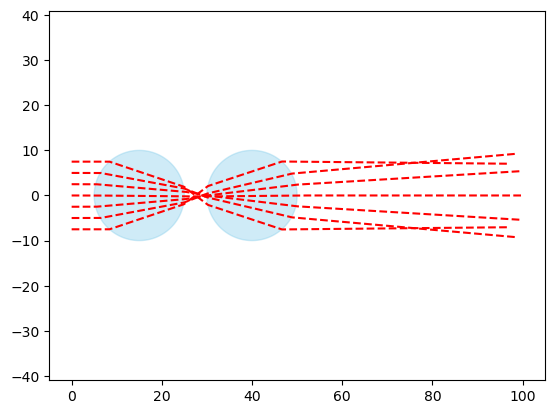

In [155]:
objects = []   #resets, clears the "board"

backgroundMedium(n=1)

ray1 = Ray(y_pos=7.5, theta=0, x_pos=0)

ray2 = Ray(y_pos=5, theta=0, x_pos=0)

ray2 = Ray(y_pos=2.5, theta=0, x_pos=0)

ray3 = Ray(y_pos=0, theta=0, x_pos=0)

ray2 = Ray(y_pos=-2.5, theta=0, x_pos=0)

ray4 = Ray(y_pos=-5, theta=0, x_pos=0)

ray5 = Ray(y_pos=-7.5, theta=0, x_pos=0)

circle1 = Circle(x_center=15, y_center=0, r=10, n=1.5, color='skyblue')

circle2 = Circle(x_center=40, y_center=0, r=10, n=1.5, color='skyblue')

for i in range(1000):
    Ray.move_all()

plotEverything()